In [ ]:
# Import OS module to work with folders and file paths
# Import matplotlib for displaying images
# Import PIL (Python Imaging Library) to open image files

In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image


In [2]:
# Define the path where the dataset is stored

# Print all folder names inside the dataset directory
# Each folder represents a waste category


In [3]:
DATASET_PATH = "dataset_4class"
print("Folders in dataset:")
print(os.listdir(DATASET_PATH))


Folders in dataset:
['Dry_Waste', 'E_Waste', 'Hazardous_Waste', 'Wet_Waste']


In [4]:
import os

category_path = "dataset_4class/Dry_Waste/cardboard"
print(os.listdir(category_path))


['cardboard1.jpg', 'cardboard10.jpg', 'cardboard100.jpg', 'cardboard101.jpg', 'cardboard102.jpg', 'cardboard103.jpg', 'cardboard104.jpg', 'cardboard105.jpg', 'cardboard106.jpg', 'cardboard107.jpg', 'cardboard108.jpg', 'cardboard109.jpg', 'cardboard11.jpg', 'cardboard110.jpg', 'cardboard111.jpg', 'cardboard112.jpg', 'cardboard113.jpg', 'cardboard114.jpg', 'cardboard115.jpg', 'cardboard116.jpg', 'cardboard117.jpg', 'cardboard118.jpg', 'cardboard119.jpg', 'cardboard12.jpg', 'cardboard120.jpg', 'cardboard121.jpg', 'cardboard122.jpg', 'cardboard123.jpg', 'cardboard124.jpg', 'cardboard125.jpg', 'cardboard126.jpg', 'cardboard127.jpg', 'cardboard128.jpg', 'cardboard129.jpg', 'cardboard13.jpg', 'cardboard130.jpg', 'cardboard131.jpg', 'cardboard132.jpg', 'cardboard133.jpg', 'cardboard134.jpg', 'cardboard135.jpg', 'cardboard136.jpg', 'cardboard137.jpg', 'cardboard138.jpg', 'cardboard139.jpg', 'cardboard14.jpg', 'cardboard140.jpg', 'cardboard141.jpg', 'cardboard142.jpg', 'cardboard143.jpg', 'cardb

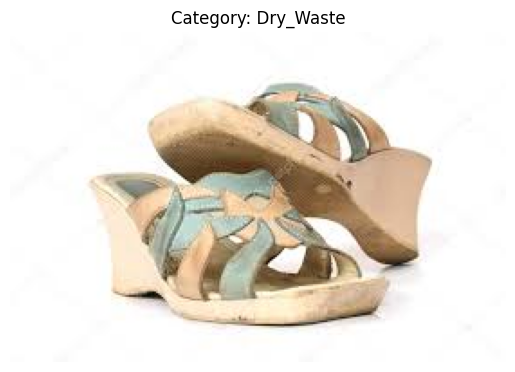

In [6]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

DATASET_PATH = "dataset_4class"

# Step 1: Pick a random category
category = random.choice(os.listdir(DATASET_PATH))
category_path = os.path.join(DATASET_PATH, category)

# Step 2: Pick a random subfolder inside the category
subfolders = [
    f for f in os.listdir(category_path)
    if os.path.isdir(os.path.join(category_path, f))
]
subfolder = random.choice(subfolders)
subfolder_path = os.path.join(category_path, subfolder)

# Step 3: Pick a random IMAGE file
image_files = [
    f for f in os.listdir(subfolder_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]
image_name = random.choice(image_files)
image_path = os.path.join(subfolder_path, image_name)

# Step 4: Open & display image
img = Image.open(image_path)
plt.imshow(img)
plt.title(f"Category: {category}")
plt.axis("off")
plt.show()


In [7]:
# Mapping dataset folder names to app-level waste categories
# This helps convert many dataset classes into 4 meaningful groups

WASTE_CATEGORY_MAPPING = {
    # Wet / Organic waste
    "biological": "Wet Waste",
    "trash": "Wet Waste",

    # Dry waste (recyclables & reusables)
    "paper": "Dry Waste",
    "cardboard": "Dry Waste",
    "plastic": "Dry Waste",
    "metal": "Dry Waste",
    "clothes": "Dry Waste",
    "shoes": "Dry Waste",

    # E-Waste
    "battery": "E-Waste",

    # Hazardous waste (glass can cause injury)
    "brown-glass": "Hazardous Waste",
    "green-glass": "Hazardous Waste",
    "white-glass": "Hazardous Waste"
}


In [8]:
# Check how each dataset category maps to final waste type

for folder in os.listdir(DATASET_PATH):
    mapped_category = WASTE_CATEGORY_MAPPING.get(folder, "Unknown")
    print(f"{folder}  -->  {mapped_category}")


Dry_Waste  -->  Unknown
E_Waste  -->  Unknown
Hazardous_Waste  -->  Unknown
Wet_Waste  -->  Unknown


In [9]:
# Import TensorFlow for building and training the model
import tensorflow as tf

# Image size expected by most CNN models (MobileNet, etc.)
IMG_SIZE = (224, 224)

# Number of images processed together
BATCH_SIZE = 32

# Percentage of data used for validation
VALIDATION_SPLIT = 0.2


In [10]:
# Load training data from dataset folder
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=42,  # ensures reproducibility
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load validation data from dataset folder
val_data = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)


Found 15126 files belonging to 4 classes.
Using 12101 files for training.
Found 15126 files belonging to 4 classes.
Using 3025 files for validation.


In [11]:
# Display detected class names
print("Detected classes:")
print(train_data.class_names)


Detected classes:
['Dry_Waste', 'E_Waste', 'Hazardous_Waste', 'Wet_Waste']


In [12]:
# Load a pre-trained MobileNetV2 model
# include_top=False removes the original classification layer
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the base model so its weights are not updated during training
base_model.trainable = False


In [13]:
# Create the full model by adding custom layers on top
model = tf.keras.Sequential([
    base_model,                         # Feature extractor
    tf.keras.layers.GlobalAveragePooling2D(),  # Reduce feature map
    tf.keras.layers.Dense(128, activation="relu"),  # Learn patterns
    tf.keras.layers.Dropout(0.3),        # Prevent overfitting
    tf.keras.layers.Dense(
        len(train_data.class_names),     # Output = number of classes
        activation="softmax"             # Multi-class classification
    )
])


In [14]:
# Compile the model with optimizer, loss function, and metrics
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [15]:
# Display the model architecture
model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
# Train the model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5  # small number for first run
)


Epoch 1/5
379/379 ━━━━━━━━━━━━━━━━━━━━ 122s 310ms/step - accuracy: 0.7880 - loss: 0.5838 - val_accuracy: 0.8106 - val_loss: 0.4818
Epoch 2/5
379/379 ━━━━━━━━━━━━━━━━━━━━ 121s 319ms/step - accuracy: 0.8268 - loss: 0.4655 - val_accuracy: 0.8063 - val_loss: 0.4853
Epoch 3/5
379/379 ━━━━━━━━━━━━━━━━━━━━ 121s 319ms/step - accuracy: 0.8368 - loss: 0.4268 - val_accuracy: 0.8380 - val_loss: 0.4197
Epoch 4/5
379/379 ━━━━━━━━━━━━━━━━━━━━ 118s 311ms/step - accuracy: 0.8511 - loss: 0.3964 - val_accuracy: 0.8499 - val_loss: 0.3964
Epoch 5/5
379/379 ━━━━━━━━━━━━━━━━━━━━ 117s 309ms/step - accuracy: 0.8556 - loss: 0.3768 - val_accuracy: 0.8446 - val_loss: 0.3987


In [17]:
model.save("waste_model.h5")
print("Model saved")


Model saved


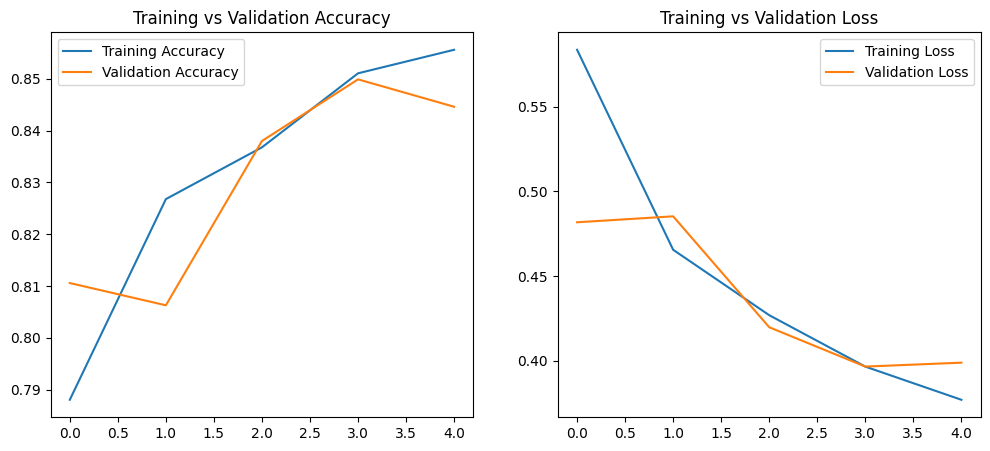

In [18]:
# Plot training & validation accuracy and loss

# Extract accuracy and loss values
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

# Create accuracy plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')

# Create loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training vs Validation Loss')

plt.show()


In [19]:
import numpy as np

# Function to predict waste category from an image path
def predict_waste(image_path):
    """
    Takes an image path as input,
    predicts the dataset class,
    and maps it to final waste category.
    """

    # Load and resize the image
    img = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    # Convert image to array
    img_array = tf.keras.utils.img_to_array(img)

    # Add batch dimension (model expects batches)
    img_array = tf.expand_dims(img_array, axis=0)

    # Normalize pixel values
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

    # Get prediction probabilities
    predictions = model.predict(img_array)

    # Get predicted class index
    predicted_index = np.argmax(predictions)

    # Get dataset class name
    predicted_class = train_data.class_names[predicted_index]

    # Map to app-level waste category
    final_category = WASTE_CATEGORY_MAPPING.get(predicted_class, "Unknown")

    return predicted_class, final_category


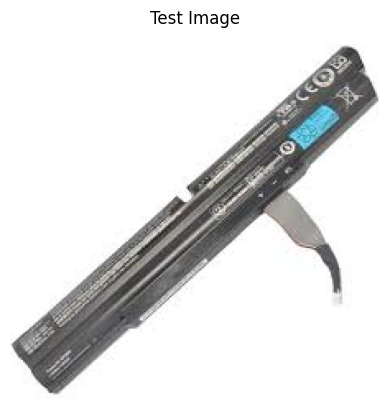

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted dataset class: Dry_Waste
Final waste category: Unknown


In [21]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

DATASET_PATH = "dataset_4class"

# Step 1: Pick a random main category
test_category = random.choice(os.listdir(DATASET_PATH))
test_category_path = os.path.join(DATASET_PATH, test_category)

# Step 2: Pick a random subfolder (like cardboard, glass, etc.)
subfolders = [
    f for f in os.listdir(test_category_path)
    if os.path.isdir(os.path.join(test_category_path, f))
]
test_subfolder = random.choice(subfolders)
test_subfolder_path = os.path.join(test_category_path, test_subfolder)

# Step 3: Pick a random image file
image_files = [
    f for f in os.listdir(test_subfolder_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]
test_image = random.choice(image_files)
test_image_path = os.path.join(test_subfolder_path, test_image)

# Step 4: Display the image
img = Image.open(test_image_path)
plt.imshow(img)
plt.axis("off")
plt.title("Test Image")
plt.show()

# Step 5: Run prediction
predicted_class, final_category = predict_waste(test_image_path)

print("Predicted dataset class:", predicted_class)
print("Final waste category:", final_category)


In [22]:
# Data augmentation to improve generalization
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])


In [23]:
# Rebuild model with data augmentation
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = tf.keras.Sequential([
    data_augmentation,                 # Apply augmentation
    tf.keras.layers.Rescaling(1./255), # Normalize pixels
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(
        len(train_data.class_names),
        activation="softmax"
    )
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [24]:
# Train the improved model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)


Epoch 1/15
379/379 ━━━━━━━━━━━━━━━━━━━━ 135s 343ms/step - accuracy: 0.8993 - loss: 0.2872 - val_accuracy: 0.9309 - val_loss: 0.1787
Epoch 2/15
379/379 ━━━━━━━━━━━━━━━━━━━━ 129s 341ms/step - accuracy: 0.9353 - loss: 0.1693 - val_accuracy: 0.9455 - val_loss: 0.1399
Epoch 3/15
379/379 ━━━━━━━━━━━━━━━━━━━━ 129s 341ms/step - accuracy: 0.9436 - loss: 0.1487 - val_accuracy: 0.9531 - val_loss: 0.1220
Epoch 4/15
379/379 ━━━━━━━━━━━━━━━━━━━━ 127s 336ms/step - accuracy: 0.9512 - loss: 0.1285 - val_accuracy: 0.9550 - val_loss: 0.1159
Epoch 5/15
379/379 ━━━━━━━━━━━━━━━━━━━━ 128s 337ms/step - accuracy: 0.9563 - loss: 0.1193 - val_accuracy: 0.9623 - val_loss: 0.0994
Epoch 6/15
379/379 ━━━━━━━━━━━━━━━━━━━━ 127s 336ms/step - accuracy: 0.9606 - loss: 0.1048 - val_accuracy: 0.9550 - val_loss: 0.1205
Epoch 7/15
379/379 ━━━━━━━━━━━━━━━━━━━━ 127s 336ms/step - accuracy: 0.9601 - loss: 0.1021 - val_accuracy: 0.9593 - val_loss: 0.1119
Epoch 8/15
379/379 ━━━━━━━━━━━━━━━━━━━━ 128s 337ms/step - accuracy: 0.9626 -

In [25]:
model.save("waste_model.keras")
print("Model saved successfully")


Model saved successfully


In [26]:
import os
print(os.path.exists("waste_model.keras"))


True


In [27]:
model.save("waste_model.h5")
print("Backup model saved")


Backup model saved


In [28]:
# Evaluate model on validation data
val_loss, val_accuracy = model.evaluate(val_data)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")


95/95 ━━━━━━━━━━━━━━━━━━━━ 23s 244ms/step - accuracy: 0.9590 - loss: 0.1326
Validation Accuracy: 95.90%


In [29]:
import numpy as np

def predict_waste(image_path):
    """
    Takes an image path and returns:
    1. Predicted dataset class (e.g., plastic)
    2. Final waste category (Dry / Wet / E / Hazardous)
    3. Confidence score (%)
    """

    # 1. Load and resize image
    img = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    # 2. Convert image to array
    img_array = tf.keras.utils.img_to_array(img)

    # 3. Add batch dimension (model expects batch input)
    img_array = tf.expand_dims(img_array, axis=0)

    # 4. Preprocess image for MobileNetV2
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

    # 5. Get prediction probabilities
    predictions = model.predict(img_array)[0]

    # 6. Find class with highest probability
    predicted_index = np.argmax(predictions)

    # 7. Confidence score
    confidence = float(predictions[predicted_index]) * 100

    # 8. Dataset-level class name
    predicted_class = train_data.class_names[predicted_index]

    # 9. Map to app-level waste category
    final_category = WASTE_CATEGORY_MAPPING.get(predicted_class, "Unknown")

    return predicted_class, final_category, confidence


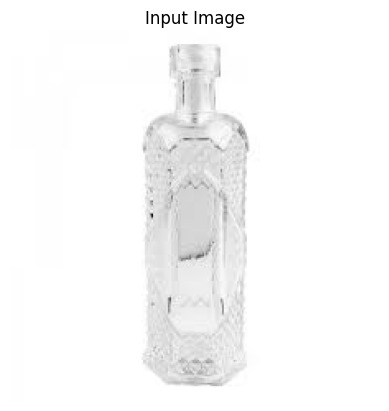

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted dataset class: Dry_Waste
Final waste category: Unknown
Confidence: 99.79%


In [31]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

DATASET_PATH = "dataset_4class"

# 1️⃣ Pick random main category
test_category = random.choice(os.listdir(DATASET_PATH))
test_category_path = os.path.join(DATASET_PATH, test_category)

# 2️⃣ Pick random subfolder (cardboard, glass, etc.)
subfolders = [
    f for f in os.listdir(test_category_path)
    if os.path.isdir(os.path.join(test_category_path, f))
]
test_subfolder = random.choice(subfolders)
test_subfolder_path = os.path.join(test_category_path, test_subfolder)

# 3️⃣ Pick random image file
image_files = [
    f for f in os.listdir(test_subfolder_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]
test_image = random.choice(image_files)
test_image_path = os.path.join(test_subfolder_path, test_image)

# 4️⃣ Display image
img = Image.open(test_image_path)
plt.imshow(img)
plt.axis("off")
plt.title("Input Image")
plt.show()

# 5️⃣ Run prediction
predicted_class, final_category, confidence = predict_waste(test_image_path)

print("Predicted dataset class:", predicted_class)
print("Final waste category:", final_category)
print(f"Confidence: {confidence:.2f}%")


In [32]:
# Reload dataset for 4-class classification
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("New class names:", train_data.class_names)


Found 15126 files belonging to 4 classes.
Using 12101 files for training.
Found 15126 files belonging to 4 classes.
Using 3025 files for validation.
New class names: ['Dry_Waste', 'E_Waste', 'Hazardous_Waste', 'Wet_Waste']


In [33]:
# Rebuild model for 4-class classification
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = tf.keras.Sequential([
    data_augmentation,
    tf.keras.layers.Rescaling(1./255),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(4, activation="softmax")  # 🔥 only 4 classes now
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_1 (Rescaling)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [34]:
# Final evaluation on validation data
val_loss, val_accuracy = model.evaluate(val_data)
print(f"Final Validation Accuracy: {val_accuracy*100:.2f}%")


95/95 ━━━━━━━━━━━━━━━━━━━━ 26s 248ms/step - accuracy: 0.1177 - loss: 1.8248
Final Validation Accuracy: 11.77%


In [35]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def predict_waste_4class(image_path):
    """
    Predict final waste category directly (4-class model)
    """

    # Load & resize image
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

    # Predict
    predictions = model.predict(img_array)[0]
    predicted_index = np.argmax(predictions)
    confidence = predictions[predicted_index] * 100

    predicted_class = train_data.class_names[predicted_index]

    return predicted_class, confidence


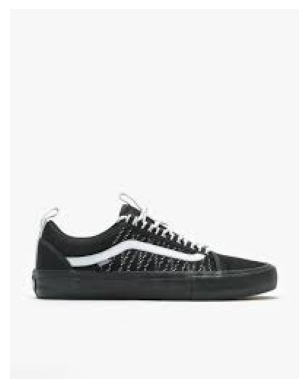

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Predicted waste category: MIXED_WASTE
Confidence: 40.90%


'print("Predicted waste category:", predicted_class)\n    print(f"Confidence: {confidence:.2f}%")\n'

In [51]:
import os, random
from PIL import Image
import matplotlib.pyplot as plt
DATASET_PATH="dataset_4class"
# Pick random category automatically
category = "Dry_Waste"
category_path = os.path.join(DATASET_PATH, category)

subfolder = random.choice(os.listdir(category_path))
subfolder_path = os.path.join(category_path, subfolder)

image_name = random.choice(os.listdir(subfolder_path))
test_image_path = os.path.join(subfolder_path, image_name)

img = Image.open(test_image_path)
plt.imshow(img)
plt.axis("off")
#plt.title(f"Input Image (Actual Folder: {category})")
plt.show()

predicted_class, confidence = predict_waste_4class(test_image_path)

'''
if predicted_class!="Dry_Waste" and confidence<50:
    print("Predicted waste category:", "MIXED_WASTE")
    print(f"Confidence: {confidence:.2f}%")
else:
    print("Predicted waste category:", predicted_class)
    print(f"Confidence: {confidence:.2f}%")
'''

print("Predicted waste category:", predicted_class)
print(f"Confidence: {confidence:.2f}%")



In [1]:
import tensorflow as tf

model = tf.keras.models.load_model("waste_model.keras")
model.summary()

ModuleNotFoundError: No module named 'tensorflow'